In [146]:
import numpy as np
from pymdp.agent import Agent

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
from IPython.display import Image, display

# reproducibility
random.seed(42)
np.random.seed(1)

In [147]:
# cell 1: grid / helper functions
n_rows, n_cols = 3, 3
n_cells = n_rows * n_cols         # 9

# hidden states (locations) -> agent, threat, shelter
n_agent = n_cells
n_threat = n_cells
n_shelter = n_cells

# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 4                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_cells

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# Controls over agent location -> actions
n_controls_agent = n_actions

# No control over threat or shelter -> Nothing
n_controls_threat = 1
n_controls_shelter = 1

def idx_to_rc(i):
    return divmod(i, n_cols)

def manhattan(i, j):
    ri, ci = idx_to_rc(i)
    rj, cj = idx_to_rc(j)
    return abs(ri - rj) + abs(ci - cj)

In [148]:
# build A (object array of modalities) - (outcomes, hidden factor 1, hf2, hf3)

A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter)) # (4, 9, 9, 9)

for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan(a,t)
            if d == 0:
                A_threat[3,a,t,s] = 0.99 # Agent observes threat intensity 3
                A_threat[2,a,t,s] = 0.01 # Noise
            elif d == 1:
                A_threat[2,a,t,s] = 0.9 # Agent observes threat intensity 2
                A_threat[1,a,t,s] = 0.1
            elif d <= 2:
                A_threat[1,a,t,s] = 0.85 # Agent observes threat intensity 1
                A_threat[0,a,t,s] = 0.15
            else:
                A_threat[0,a,t,s] = 1.0 # Agent observes no threat nearby

A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter)) # (2, 9, 9, 9)

for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            if a == s:
                A_shelter[1,a,t,s] = 0.99 # Agent is at shelter
                A_shelter[0,a,t,s] = 0.01 # small noise
            else:
                A_shelter[0,a,t,s] = 0.99
                A_shelter[1,a,t,s] = 0.01

A_shelter /= A_shelter.sum(axis=0, keepdims=True)

A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter)) # (9, 9, 9, 9)
for a in range(n_agent):
    A_agent[a,a,:,:] = 0.95
    A_agent[:,a,:,:] += (0.05 / (n_agent_obs - 1))  # small noise

A_agent /= A_agent.sum(axis=0, keepdims=True)


# pack into an object array (three modalities)
A = np.empty(3, dtype=object)
A[0] = A_threat
A[1] = A_shelter
A[2] = A_agent

# quick sanity
for i in range(3):
    print(f"A[{i}] shape:", A[i].shape)
print("A type: ", A.dtype)


A[0] shape: (4, 9, 9, 9)
A[1] shape: (2, 9, 9, 9)
A[2] shape: (9, 9, 9, 9)
A type:  object


In [149]:
# build B object array (one element per hidden-state factor)
def idx_to_xy(idx):
    return (idx // n_cols, idx % n_cols)

def xy_to_idx(x, y):
    return x * n_cols + y

def step_from(idx, action):
    x, y = idx_to_xy(idx)
    if action == 0:   # up
        nx, ny = x-1, y
    elif action == 1: # down
        nx, ny = x+1, y
    elif action == 2: # left
        nx, ny = x, y-1
    elif action == 3: # right
        nx, ny = x, y+1
    elif action == 4: # stay
        nx, ny = x, y
    else:
        raise ValueError("bad action")
    # out-of-bounds => stay in place
    if nx < 0 or nx >= n_rows or ny < 0 or ny >= n_cols:
        return idx
    return xy_to_idx(nx, ny)

B = np.empty(3, dtype=object)

# build B for agent factor
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_cells):
    for a in range(n_actions):
        ns = step_from(s, a)
        B_agent[ns, s, a] = 0.99   # nearly deterministic
        B_agent[:, s, a] += (0.01 / (n_agent-1))

# normalize cols
B_agent /= B_agent.sum(axis=0)

# B for threat and shelter factors -> Don't move at all, so I(n_cols)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s,s,0] = 1.0


B_shelter = np.zeros((n_shelter, n_shelter, 1))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.00


# sanity checks:
# each (s,a) column sums to 1
col_sums = B_agent.sum(axis=0)        # shape (n_cells, n_actions)
if not np.allclose(col_sums, 1.0):
    raise RuntimeError("B_agent columns not normalized - check construction")
print("B_agent constructed OK. shape:", B_agent.shape)

B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter


B_agent constructed OK. shape: (9, 9, 5)


In [150]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_threat = np.array([-0.10, -0.10, -0.12, -0.15])  # more negative -> avoid
C_threat = np.log(softmax(U_threat))
# shelter: [not_at, at] -> prefer being at shelter (positive)
U_shelter = np.array([0.5, 1.0]) # positive for being in shelter
C_shelter = np.log(softmax(U_shelter))
# agent proprio: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 1
C = [C_threat[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

C (log pref): [array([[-1.36900274],
       [-1.36900274],
       [-1.38900274],
       [-1.41900274]]), array([[-0.97407698],
       [-0.47407698]]), array([[-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458],
       [-2.19722458]])]


In [151]:
# Agent initial prior: start in some corner or uniform
D_agent = np.zeros(n_agent); D_agent[0] = 1.0   # start at top-left (shelter)

# Threat prior: unknown -> uniform
D_threat = np.ones(n_threat) / n_threat

# Shelter prior: known, one-hot at chosen shelter index
shelter_index = 0   # cell index for shelter -> top left
D_shelter = np.zeros(n_shelter); D_shelter[shelter_index] = 1.0

D = [D_agent, D_threat, D_shelter]


In [152]:
# BLOCK B: Ensure C and D are in the same object-array format pymdp expects
# Your notebook currently made C as Python list of arrays and D as list; convert to object arrays.

# policy_len / horizon - you already set T = policy_len = 4 above; keep that
policy_len = T

# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

# Convert D (list) to object array (one per hidden factor)
D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C and D converted to object-arrays for pymdp.
C shapes: [(4, 1), (2, 1), (9, 1)]
D shapes: [(9,), (9,), (9,)]


In [153]:
# BLOCK C: Generate policies for threat task
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1]

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Returns list of arrays shape (policy_len, n_control_factors),
    where first column is agent actions, others are dummy zeros.
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)
print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)


Generated 5 policies (h=1, n_actions=5).
policy[0] shape: (1, 3)


In [154]:
# BLOCK D: Habit prior (E) represented as decaying Dirichlet counts -> assign to agent_obj.E each step
E_base_count = 1.0
E_counts = np.ones(n_policies) * E_base_count    # Dirichlet-like pseudo-counts

# Hyperparameters (tune these)
E_decay_rate = 0.15        # forgetting speed (0 = never forget; higher -> faster forget)
E_reinforce_amt = 2.0      # bump when hide-after-confirm succeeds
threat_detection_threshold = 0.3  # posterior mass threshold to call threat 'confirmed'

def counts_to_probs(counts):
    return counts / (counts.sum() + 1e-16)

def decay_counts_toward_base(counts, decay_rate, base):
    return (1.0 - decay_rate) * counts + decay_rate * base


In [155]:
# BLOCK E: observation sampling from A and render function (matplotlib -> PNG -> numpy array)
def sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A):
    """
    A is object array: A[0] threat (4 x agent x threat x shelter),
                             A[1] shelter (2 x agent x threat x shelter),
                             A[2] agent (9 x agent x threat x shelter)
    Returns list of ints: [obs_threat_intensity, obs_shelter_presence, obs_agent_loc]
    """
    # modality 0: threat intensity
    p_o_threat = A[0][:, true_agent_pos, true_threat_pos, true_shelter_pos]
    p_o_threat = p_o_threat / (np.sum(p_o_threat) + 1e-16)
    obs_threat = int(np.random.choice(len(p_o_threat), p=p_o_threat))

    # modality 1: shelter presence
    p_o_shel = A[1][:, true_agent_pos, true_threat_pos, true_shelter_pos]
    p_o_shel = p_o_shel / (np.sum(p_o_shel) + 1e-16)
    obs_shel = int(np.random.choice(len(p_o_shel), p=p_o_shel))

    # modality 2: agent proprio (observing own location)
    p_o_agent = A[2][:, true_agent_pos, true_threat_pos, true_shelter_pos]
    p_o_agent = p_o_agent / (np.sum(p_o_agent) + 1e-16)
    obs_agent = int(np.random.choice(len(p_o_agent), p=p_o_agent))

    return [obs_threat, obs_shel, obs_agent]

# render grid to image: similar to mouse-cheese but highlight threat & shelter
def render_grid_frame(agent_pos, threat_pos, shelter_pos, visited, step, threat_posterior=None):
    """
    Draw 3x3 grid; agent (blue), threat (pink), shelter (green). Optionally overlay threat posterior heatmap.
    """
    fig, ax = plt.subplots(figsize=(3,3), dpi=100)   # 300x300 px
    ax.set_xlim(0,3); ax.set_ylim(0,3)
    ax.set_xticks([]); ax.set_yticks([])
    plt.gca().set_aspect('equal', adjustable='box')
    ax.set_title(f"Step {step}")

    for i in range(3):
        for j in range(3):
            idx = i*3 + j
            if idx == agent_pos:
                color = "blue"
            elif idx == threat_pos:
                color = "#ff9999"   # pinkish threat
            elif idx == shelter_pos:
                color = "#99ff99"   # greenish shelter
            elif idx in visited:
                color = "lightgray"
            else:
                color = "white"
            ax.add_patch(plt.Rectangle((j, 2-i), 1, 1, facecolor=color, edgecolor="black"))

    # overlay threat posterior heatmap if provided
    if threat_posterior is not None:
        heat = np.array(threat_posterior).reshape((3,3))
        ax.imshow(heat, extent=(0,3,0,3), origin='upper',
                  cmap='Reds', alpha=0.45, interpolation='nearest',
                  vmin=0, vmax=max(heat.max(), 1))

    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor=fig.get_facecolor())
    buf.seek(0)
    img = imageio.v2.imread(buf)
    buf.close()
    plt.close(fig)

    if img.shape[-1] == 4:
        img = img[..., :3]
    return img.copy()


In [156]:
# BLOCK F: Create the Agent (same args style as mouse-cheese)
# control facets: [n_actions, 1, 1]
agent_obj = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 4.0,
    alpha = 8.0,
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")
print("Number of policies:", len(agent_obj.policies))


Agent constructed.
Number of policies: 5


In [157]:
# BLOCK G: run simulation — set agent_obj.E from E_counts before infer_policies()
max_steps = 250
frames = []
history = {'true_state':[], 'beliefs':[], 'actions':[], 'policy_idx':[], 'E_counts':[]}

# initialize true positions (use D_agent and D_shelter as before)
true_shelter_pos = int(shelter_index)
true_threat_pos = int(n_cells - 1)    # bottom-right by default
if np.isclose(np.sum(D_agent), 1.0) and np.max(D_agent) == 1.0:
    true_agent_pos = int(np.argmax(D_agent))
else:
    true_agent_pos = int(np.random.choice(n_agent, p=D_agent))

visited = {true_agent_pos}

for t in range(max_steps):
    # 1) sample observation from current true state (the environment emits obs for current state)
    obs = sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A)

    # 2) set Habit prior E from counts (normalized) BEFORE calling infer_policies
    agent_obj.E = counts_to_probs(E_counts)

    # 3) standard pymdp inference calls
    qs = agent_obj.infer_states(obs)         # updates agent_obj.qs
    q_pi_agent, neg_efe = agent_obj.infer_policies()

    # 4) sample policy from q_pi_agent (pymdp already used E internally)
    chosen_policy_idx = int(np.random.choice(len(policies), p=q_pi_agent))
    chosen_policy = policies[chosen_policy_idx]
    chosen_action = int(chosen_policy[0, 0])

    # 5) apply chosen action to the environment (use step_from defined earlier)
    next_agent_pos = step_from(true_agent_pos, chosen_action)

    # 6) check threat confirmation (using agent_obj.qs[1] posterior over threat)
    threat_confirmed = False
    shelter_reached = False
    if hasattr(agent_obj, "qs") and agent_obj.qs is not None:
        q_threat = agent_obj.qs[1]   # posterior over threat factor
        if float(q_threat[true_threat_pos]) > threat_detection_threshold:
            threat_confirmed = True
            print(f'Threat confirmed on step {t}!')
    # 7) check if agent will be at shelter after applying action
    if next_agent_pos == true_shelter_pos:
        shelter_reached = True

    # 8) reinforce habit counts if confirmed threat then reached shelter
    if threat_confirmed and shelter_reached:
        E_counts[chosen_policy_idx] += E_reinforce_amt

    # 9) forgetting: decay E_counts toward base
    E_counts = decay_counts_toward_base(E_counts, E_decay_rate, E_base_count)

    # 10) record & render
    true_agent_pos = next_agent_pos
    visited.add(true_agent_pos)
    frame_img = render_grid_frame(true_agent_pos, true_threat_pos, true_shelter_pos, visited, t,
                                  threat_posterior=(agent_obj.qs[1] if (hasattr(agent_obj, "qs") and agent_obj.qs is not None) else None))
    frames.append(frame_img)

    history['true_state'].append(true_agent_pos)
    history['beliefs'].append(agent_obj.qs.copy() if hasattr(agent_obj, "qs") else None)
    history['actions'].append(chosen_action)
    history['policy_idx'].append(chosen_policy_idx)
    history['E_counts'].append(E_counts.copy())

    if t % 10 == 0:
        print(f"step {t:03d} | true_agent={true_agent_pos} | action={actions[chosen_action]} | policy_idx={chosen_policy_idx}")
        print(f"  threat_confirmed={threat_confirmed} shelter_reached={shelter_reached}")
        top_idx = np.argsort(E_counts)[-3:][::-1]
        print("  top E_counts (idx, count):", [(int(i), float(E_counts[i])) for i in top_idx])

print("Simulation finished.")


step 000 | true_agent=3 | action=down | policy_idx=1
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 010 | true_agent=8 | action=down | policy_idx=1
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 020 | true_agent=4 | action=down | policy_idx=1
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 030 | true_agent=0 | action=up | policy_idx=0
  threat_confirmed=False shelter_reached=True
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 040 | true_agent=2 | action=stay | policy_idx=4
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 050 | true_agent=2 | action=right | policy_idx=3
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
step 060 | true_agent=0 | action=up | poli

Saved threat_with_E.gif


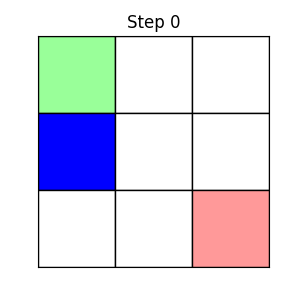

Top policy indices by E (final): [4 3 2 1 0]
4 [[4 0 0]] E_prob=0.2000 count=1.00
3 [[3 0 0]] E_prob=0.2000 count=1.00
2 [[2 0 0]] E_prob=0.2000 count=1.00
1 [[1 0 0]] E_prob=0.2000 count=1.00
0 [[0 0 0]] E_prob=0.2000 count=1.00


In [158]:
# BLOCK 8: save gif and print top habit policies
gif_path = "threat_with_E.gif"
imageio.mimsave(gif_path, frames, fps=7)
print(f"Saved {gif_path}")
display(Image(gif_path))

# final normalized E
E_final = counts_to_probs(E_counts)
topk = 8
top_idx = np.argsort(E_final)[-topk:][::-1]
print("Top policy indices by E (final):", top_idx)
for i in top_idx:
    print(i, policies[i], f"E_prob={E_final[i]:.4f} count={E_counts[i]:.2f}")